In [1]:
# 1. 非线性激活函数的重要性
import sympy as sp
x = sp.Symbol('x')
W1 = sp.Symbol('W1')
b1 = sp.Symbol('b1')
W2 = sp.Symbol('W2')
b2 = sp.Symbol('b2')
h = W1 * x + b1
o = W2 * h + b2
o_expand = sp.expand(o)
o_expand

W1*W2*x + W2*b1 + b2

In [2]:
# 2. 激活函数性质分析
import sympy as sp
x = sp.Symbol('x')
# Sigmoid
sigmoid = 1 / (1 + sp.exp(-x))
sigmoid_diff = sp.diff(sigmoid, x)
sigmoid_simp = sp.simplify(sigmoid_diff)
# tanh
tanh = sp.tanh(x)
tanh_diff = sp.diff(tanh, x)
tanh_simp = sp.simplify(tanh_diff)
sigmoid, sigmoid_diff, sigmoid_simp, tanh, tanh_diff, tanh_simp

(1/(1 + exp(-x)),
 exp(-x)/(1 + exp(-x))**2,
 1/(4*cosh(x/2)**2),
 tanh(x),
 1 - tanh(x)**2,
 cosh(x)**(-2))

未能使用 torchvision (或版本不兼容)： ModuleNotFoundError("No module named 'torchvision'")
手动下载并解析 Fashion-MNIST 完成： (60000, 784) (60000,) (10000, 784) (10000,)
Epoch 1, Loss: 0.3338, Train Acc: 0.8169, Test Acc: 0.8044
Epoch 2, Loss: 0.3210, Train Acc: 0.8352, Test Acc: 0.8225
Epoch 3, Loss: 0.7532, Train Acc: 0.7846, Test Acc: 0.7729
Epoch 4, Loss: 0.2646, Train Acc: 0.8618, Test Acc: 0.8467
Epoch 5, Loss: 0.7225, Train Acc: 0.8479, Test Acc: 0.8333
Epoch 6, Loss: 0.3748, Train Acc: 0.8711, Test Acc: 0.8525
Epoch 7, Loss: 0.2171, Train Acc: 0.8707, Test Acc: 0.8529
Epoch 8, Loss: 0.1783, Train Acc: 0.8777, Test Acc: 0.8589
Epoch 9, Loss: 0.3834, Train Acc: 0.8760, Test Acc: 0.8597
Epoch 10, Loss: 0.3350, Train Acc: 0.8744, Test Acc: 0.8545
Epoch 11, Loss: 0.2038, Train Acc: 0.8837, Test Acc: 0.8653
Epoch 12, Loss: 0.2498, Train Acc: 0.8662, Test Acc: 0.8465
Epoch 13, Loss: 0.4035, Train Acc: 0.8814, Test Acc: 0.8617
Epoch 14, Loss: 0.3628, Train Acc: 0.8908, Test Acc: 0.8711
Epoch 15, Loss: 0.1

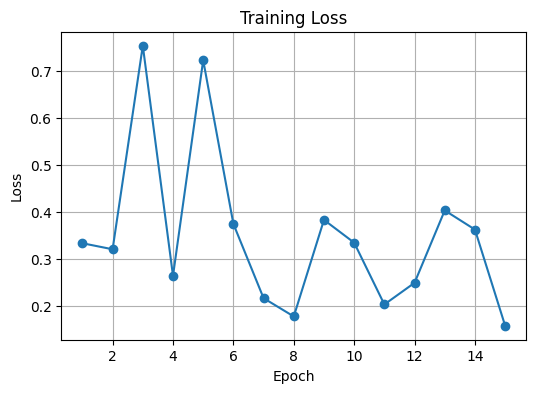

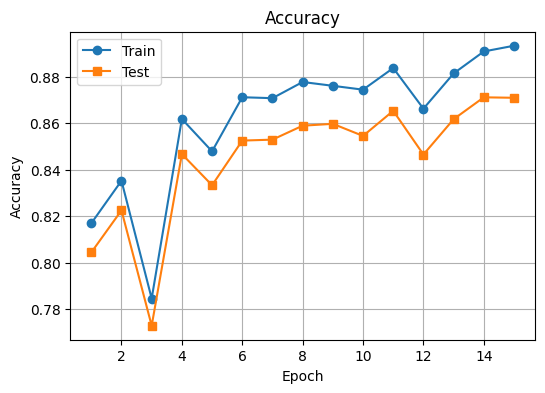

模型参数已保存到 ./mlp_params.pth 以及 mlp_params.npz
训练指标已保存到 ./training_metrics.npz
Final Test Accuracy: 0.8709


In [11]:
# 2.2 编程题：手写单隐藏层MLP（尽量不依赖 torchvision）
import os
import sys
import gzip
import struct
import urllib.request
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
# 设定随机种子以保证可复现
torch.manual_seed(42)
np.random.seed(42)

# 数据加载：优先使用 torchvision，否则回退到手动下载解析 Fashion-MNIST 的 IDX 文件
DATA_DIR = './data/fashion-mnist'
os.makedirs(DATA_DIR, exist_ok=True)

def try_import_torchvision():
    try:
        import torchvision
        import torchvision.transforms as transforms
        print('使用 torchvision 加载数据')
        return torchvision, transforms
    except Exception as e:
        print('未能使用 torchvision (或版本不兼容)：', repr(e))
        return None, None

def download_url(url, filename):
    if os.path.exists(filename):
        return filename
    print('Downloading', url)
    urllib.request.urlretrieve(url, filename)
    return filename

# IDX 解析函数
def parse_idx_images(filename):
    with gzip.open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        data = f.read()
        images = np.frombuffer(data, dtype=np.uint8).reshape(num, rows*cols)
    return images

def parse_idx_labels(filename):
    with gzip.open(filename, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        data = f.read()
        labels = np.frombuffer(data, dtype=np.uint8)
    return labels

def load_fashion_mnist_fallback(data_dir=DATA_DIR):
    base = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/'
    files = {
        'train_images':'train-images-idx3-ubyte.gz',
        'train_labels':'train-labels-idx1-ubyte.gz',
        'test_images':'t10k-images-idx3-ubyte.gz',
        'test_labels':'t10k-labels-idx1-ubyte.gz',
    }
    paths = {}
    for k, fname in files.items():
        url = base + fname
        local = os.path.join(data_dir, fname)
        try:
            download_url(url, local)
        except Exception as e:
            raise RuntimeError(f'无法下载 {url}: {e}')
        paths[k] = local
    X_train = parse_idx_images(paths['train_images']).astype(np.float32) / 255.0
    y_train = parse_idx_labels(paths['train_labels']).astype(np.int64)
    X_test = parse_idx_images(paths['test_images']).astype(np.float32) / 255.0
    y_test = parse_idx_labels(paths['test_labels']).astype(np.int64)
    print('手动下载并解析 Fashion-MNIST 完成：', X_train.shape, y_train.shape, X_test.shape, y_test.shape)
    return X_train, y_train, X_test, y_test

# 尝试用 torchvision 加载数据集
torchvision, transforms = try_import_torchvision()
if torchvision is not None:
    transform = transforms.Compose([transforms.ToTensor(), lambda x: x.view(-1)])
    train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
else:
    # 回退到手动下载并解析数据，然后构造 DataLoader
    X_train, y_train, X_test, y_test = load_fashion_mnist_fallback(DATA_DIR)
    train_tensor_x = torch.from_numpy(X_train)
    train_tensor_y = torch.from_numpy(y_train)
    test_tensor_x = torch.from_numpy(X_test)
    test_tensor_y = torch.from_numpy(y_test)
    train_dataset = TensorDataset(train_tensor_x, train_tensor_y)
    test_dataset = TensorDataset(test_tensor_x, test_tensor_y)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# 2. 手动初始化参数
input_dim = 28*28
hidden_dim = 128
output_dim = 10
device = torch.device('cpu')
W1 = torch.randn(input_dim, hidden_dim, dtype=torch.float32, device=device) * 0.01
b1 = torch.zeros(hidden_dim, dtype=torch.float32, device=device)
W2 = torch.randn(hidden_dim, output_dim, dtype=torch.float32, device=device) * 0.01
b2 = torch.zeros(output_dim, dtype=torch.float32, device=device)

# 3. ReLU激活函数
def relu(x):
    return torch.maximum(x, torch.zeros_like(x))

# 4. Softmax+交叉熵损失（手动实现）
def softmax(x):
    x = x - x.max(dim=1, keepdim=True)[0]
    exp_x = torch.exp(x)
    return exp_x / exp_x.sum(dim=1, keepdim=True)

def cross_entropy(pred, target):
    probs = softmax(pred)
    batch_size = pred.shape[0]
    log_probs = torch.log(probs[range(batch_size), target] + 1e-12)
    loss = -log_probs.mean()
    return loss

# 5. 前向传播
def forward(x, W1, b1, W2, b2):
    h = relu(x @ W1 + b1)
    o = h @ W2 + b2
    return o, h

# 6. 训练循环（Mini-batch SGD）
lr = 0.05
num_epochs = 15
loss_history = []
train_acc_history = []
test_acc_history = []
for epoch in range(num_epochs):
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device).float()
        batch_y = batch_y.to(device).long()
        # 前向
        logits, h = forward(batch_x, W1, b1, W2, b2)
        loss = cross_entropy(logits, batch_y)
        # 反向传播（手动求导）
        batch_size = batch_x.shape[0]
        probs = softmax(logits)
        probs_copy = probs.clone()
        probs_copy[range(batch_size), batch_y] -= 1
        probs_copy /= batch_size
        # 输出层梯度
        dW2 = h.t() @ probs_copy
        db2 = probs_copy.sum(0)
        # 隐藏层梯度
        dh = probs_copy @ W2.t()
        dh = dh * (h > 0).float()
        dW1 = batch_x.t() @ dh
        db1 = dh.sum(0)
        # 参数更新（in-place）
        with torch.no_grad():
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2
        running_loss = loss.item()
    loss_history.append(running_loss)
    # 每 epoch 计算训练和测试精度
    def evaluate(loader):
        correct, total = 0, 0
        for x, y in loader:
            x = x.to(device).float()
            y = y.to(device).long()
            logits, _ = forward(x, W1, b1, W2, b2)
            pred = logits.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
        return correct / total
    train_acc = evaluate(train_loader)
    test_acc = evaluate(test_loader)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

# 7. 绘制训练损失与精度曲线并保存模型参数与指标
plt.figure(figsize=(6,4))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(range(1, len(train_acc_history)+1), train_acc_history, marker='o', label='Train')
plt.plot(range(1, len(test_acc_history)+1), test_acc_history, marker='s', label='Test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 保存模型参数到文件（.pth 和 .npz）
model_path = './mlp_params.pth'
torch.save({'W1': W1.cpu(), 'b1': b1.cpu(), 'W2': W2.cpu(), 'b2': b2.cpu()}, model_path)
np.savez('./mlp_params.npz', W1=W1.cpu().numpy(), b1=b1.cpu().numpy(), W2=W2.cpu().numpy(), b2=b2.cpu().numpy())
print('模型参数已保存到', model_path, '以及 mlp_params.npz')

# 保存训练指标
np.savez('./training_metrics.npz', loss=np.array(loss_history), train_acc=np.array(train_acc_history), test_acc=np.array(test_acc_history))
print('训练指标已保存到 ./training_metrics.npz')

# 8. 最终测试准确率
final_test_acc = test_acc_history[-1] if len(test_acc_history)>0 else evaluate(test_loader)
print(f"Final Test Accuracy: {final_test_acc:.4f}")

degree | train MSE | test MSE
     1 |    0.2610 |    0.2414
     3 |    0.0526 |    0.0503
     9 |    0.0249 |    0.0705
    15 |    0.0000 |   46.6281


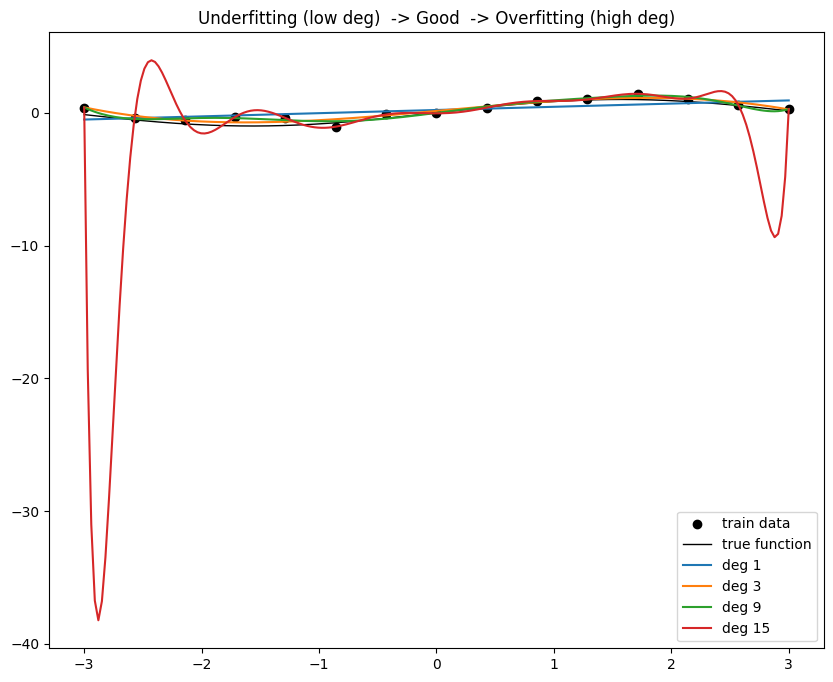

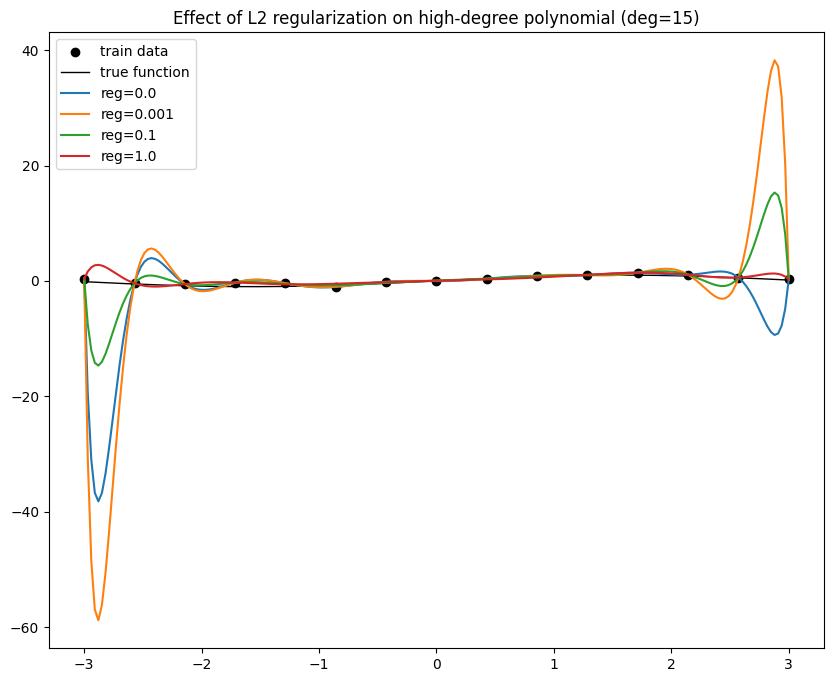


结论示例：
 - 低次多项式（degree=1）通常欠拟合：训练误差与测试误差都高。
 - 适中次数（degree=3）可较好拟合。
 - 高次多项式（degree=15）在训练集上误差很低但测试集误差高（过拟合）。
 - 对高次模型使用 L2 正则化 可以降低测试误差（缓解过拟合）。


In [12]:
# 理论题 1：过拟合与欠拟合 演示（多项式回归，闭式解）
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# 生成真实函数和数据
def true_fn(x):
    return np.sin(x)

# 训练集少、测试集多用于展示
x_train = np.linspace(-3, 3, 15)
y_train = true_fn(x_train) + 0.3 * np.random.randn(len(x_train))

x_test = np.linspace(-3, 3, 200)
y_test = true_fn(x_test)

# 多项式基函数
def poly_features(x, degree):
    x = np.asarray(x)
    return np.vander(x, N=degree+1, increasing=True)

# 闭式解（带 L2 正则项 reg）
def fit_poly_closedform(x, y, degree, reg=0.0):
    Phi = poly_features(x, degree)  # [N, D]
    D = Phi.shape[1]
    A = Phi.T @ Phi + reg * np.eye(D)
    b = Phi.T @ y
    w = np.linalg.solve(A, b)
    return w

def predict_poly(w, x):
    Phi = poly_features(x, len(w)-1)
    return Phi @ w

# 评估不同复杂度
degrees = [1, 3, 9, 15]
results = []
for deg in degrees:
    w = fit_poly_closedform(x_train, y_train, deg, reg=0.0)
    y_train_pred = predict_poly(w, x_train)
    y_test_pred = predict_poly(w, x_test)
    train_mse = np.mean((y_train_pred - y_train)**2)
    test_mse = np.mean((y_test_pred - y_test)**2)
    results.append((deg, train_mse, test_mse))

# 显示结果
print('degree | train MSE | test MSE')
for deg, tr, te in results:
    print(f'{deg:6d} | {tr:9.4f} | {te:9.4f}')

# 绘图：真实函数、训练点以及各模型预测
plt.figure(figsize=(10,8))
plt.scatter(x_train, y_train, color='black', label='train data')
plt.plot(x_test, y_test, label='true function', color='k', linewidth=1)
colors = ['C0','C1','C2','C3']
for i, deg in enumerate(degrees):
    w = fit_poly_closedform(x_train, y_train, deg, reg=0.0)
    y_pred = predict_poly(w, x_test)
    plt.plot(x_test, y_pred, color=colors[i], label=f'deg {deg}')
plt.legend()
plt.title('Underfitting (low deg)  -> Good  -> Overfitting (high deg)')
plt.show()

# 展示正则化如何缓解过拟合（用高次多项式 deg=15）
deg = 15
regs = [0.0, 1e-3, 1e-1, 1.0]
plt.figure(figsize=(10,8))
plt.scatter(x_train, y_train, color='black', label='train data')
plt.plot(x_test, y_test, label='true function', color='k', linewidth=1)
for reg in regs:
    w = fit_poly_closedform(x_train, y_train, deg, reg=reg)
    y_pred = predict_poly(w, x_test)
    plt.plot(x_test, y_pred, label=f'reg={reg}')
plt.legend()
plt.title('Effect of L2 regularization on high-degree polynomial (deg=15)')
plt.show()

print('\n结论示例：')
print(' - 低次多项式（degree=1）通常欠拟合：训练误差与测试误差都高。')
print(' - 适中次数（degree=3）可较好拟合。')
print(' - 高次多项式（degree=15）在训练集上误差很低但测试集误差高（过拟合）。')
print(' - 对高次模型使用 L2 正则化 可以降低测试误差（缓解过拟合）。')

In [13]:
# 理论题 2：K 折交叉验证实现（用于多项式回归超参数选择）
import numpy as np
from math import ceil

def k_fold_indices(n, k, shuffle=True, seed=None):
    idx = np.arange(n)
    if shuffle:
        rng = np.random.RandomState(seed)
        rng.shuffle(idx)
    folds = np.array_split(idx, k)
    return folds

def k_fold_cv(x, y, degree, reg, k=5, seed=0):
    n = len(x)
    folds = k_fold_indices(n, k, shuffle=True, seed=seed)
    vals = []
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j!=i])
        w = fit_poly_closedform(x[train_idx], y[train_idx], degree, reg=reg)
        y_val_pred = predict_poly(w, x[val_idx])
        mse = np.mean((y_val_pred - y[val_idx])**2)
        vals.append(mse)
    return np.mean(vals), np.std(vals)

# 超参数搜索示例：在 degree 与 reg 上网格搜索
x_all = np.concatenate([x_train, x_test])  # 注意：此处仅为演示，实际CV应只用训练集合
y_all = np.concatenate([y_train, y_test])

# 实际使用时，应把原始数据分为训练集和独立测试集；这里示范CV流程
degrees = [1,3,5,7,9]
regs = [0.0, 1e-4, 1e-2, 1e-1]

best = None
for deg in degrees:
    for reg in regs:
        mean_mse, std_mse = k_fold_cv(x_train, y_train, deg, reg, k=5, seed=42)
        print(f'deg={deg}, reg={reg:.4g} -> CV MSE={mean_mse:.4f} ± {std_mse:.4f}')
        if best is None or mean_mse < best[0]:
            best = (mean_mse, deg, reg)

print('\nBest CV config: MSE={:.4f}, degree={}, reg={}'.format(best[0], best[1], best[2]))

# 用最佳超参数在完整训练集上训练并评估（此处用之前的 test 集）
best_deg = best[1]
best_reg = best[2]
w_best = fit_poly_closedform(x_train, y_train, best_deg, reg=best_reg)
y_test_pred = predict_poly(w_best, x_test)
test_mse = np.mean((y_test_pred - y_test)**2)
print('Test MSE with best CV hyperparams:', test_mse)


deg=1, reg=0 -> CV MSE=0.3686 ± 0.2900
deg=1, reg=0.0001 -> CV MSE=0.3686 ± 0.2900
deg=1, reg=0.01 -> CV MSE=0.3685 ± 0.2899
deg=1, reg=0.1 -> CV MSE=0.3676 ± 0.2897
deg=3, reg=0 -> CV MSE=0.0936 ± 0.0617
deg=3, reg=0.0001 -> CV MSE=0.0936 ± 0.0617
deg=3, reg=0.01 -> CV MSE=0.0936 ± 0.0617
deg=3, reg=0.1 -> CV MSE=0.0935 ± 0.0619
deg=5, reg=0 -> CV MSE=0.3424 ± 0.2943
deg=5, reg=0.0001 -> CV MSE=0.3424 ± 0.2942
deg=5, reg=0.01 -> CV MSE=0.3384 ± 0.2888
deg=5, reg=0.1 -> CV MSE=0.3093 ± 0.2479
deg=7, reg=0 -> CV MSE=0.3530 ± 0.4871
deg=7, reg=0.0001 -> CV MSE=0.3531 ± 0.4872
deg=7, reg=0.01 -> CV MSE=0.3679 ± 0.4994
deg=7, reg=0.1 -> CV MSE=0.5658 ± 0.6973
deg=9, reg=0 -> CV MSE=38.6938 ± 48.7756
deg=9, reg=0.0001 -> CV MSE=38.5087 ± 48.4918
deg=9, reg=0.01 -> CV MSE=27.0425 ± 32.9137
deg=9, reg=0.1 -> CV MSE=10.2152 ± 17.0105

Best CV config: MSE=0.0935, degree=3, reg=0.1
Test MSE with best CV hyperparams: 0.05086662840650713



Running config: no_reg
Epoch 1, Train Loss: 2.2422, Val Loss: 2.2570
Epoch 2, Train Loss: 2.1218, Val Loss: 2.1605
Epoch 3, Train Loss: 1.9263, Val Loss: 1.9909
Epoch 4, Train Loss: 1.7093, Val Loss: 1.8301
Epoch 5, Train Loss: 1.5641, Val Loss: 1.7554
Epoch 6, Train Loss: 1.4609, Val Loss: 1.6084
Epoch 7, Train Loss: 1.2802, Val Loss: 1.4227
Epoch 8, Train Loss: 1.1737, Val Loss: 1.3310
Epoch 9, Train Loss: 1.0375, Val Loss: 1.2689
Epoch 10, Train Loss: 1.1985, Val Loss: 1.4077
Epoch 11, Train Loss: 0.9694, Val Loss: 1.2465
Epoch 12, Train Loss: 0.8949, Val Loss: 1.2026
Epoch 13, Train Loss: 0.8530, Val Loss: 1.1345
Epoch 14, Train Loss: 0.8246, Val Loss: 1.1692
Epoch 15, Train Loss: 0.7358, Val Loss: 0.9579
Epoch 16, Train Loss: 1.0100, Val Loss: 1.3813
Epoch 17, Train Loss: 0.6545, Val Loss: 1.0099
Epoch 18, Train Loss: 0.7115, Val Loss: 0.9795
Epoch 19, Train Loss: 0.9954, Val Loss: 1.2855
Epoch 20, Train Loss: 1.2284, Val Loss: 1.7433
Epoch 21, Train Loss: 1.0520, Val Loss: 1.567

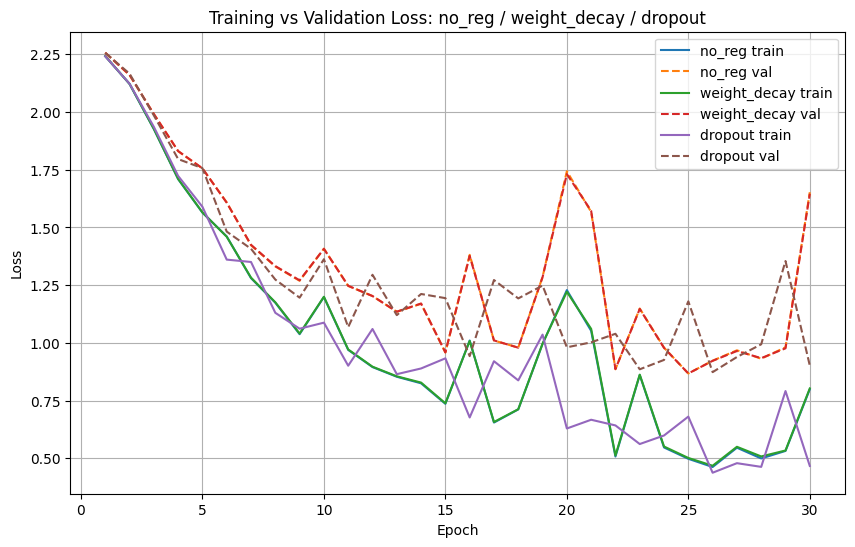


对比实验完成，结果保存在 notebook 输出中。


In [14]:
# 实验：在手写 MLP 上加入 L2 权重衰减与 Dropout，并做对比实验
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset

# Dropout 从零实现
def dropout_layer(X, dropout, is_training=True):
    if (not is_training) or dropout <= 0.0:
        return X, None
    mask = (torch.rand_like(X) > dropout).float()
    scale = 1.0 / (1.0 - dropout)
    return X * mask * scale, mask

# 基于现有 relu, softmax, cross_entropy 函数
# 训练函数（返回 train_loss_hist, val_loss_hist）
def train_mlp_custom(X_train, y_train, X_val, y_val, hidden_dim=128, lr=0.1,
                     weight_decay=0.0, dropout_p=0.0, num_epochs=30, batch_size=32, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    device = torch.device('cpu')
    N, input_dim = X_train.shape
    output_dim = int(y_train.max().item()) + 1 if isinstance(y_train, torch.Tensor) else int(y_train.max())+1

    W1 = torch.randn(input_dim, hidden_dim, dtype=torch.float32, device=device) * 0.01
    b1 = torch.zeros(hidden_dim, dtype=torch.float32, device=device)
    W2 = torch.randn(hidden_dim, output_dim, dtype=torch.float32, device=device) * 0.01
    b2 = torch.zeros(output_dim, dtype=torch.float32, device=device)

    def forward_dropout(x, is_training):
        h_lin = x @ W1 + b1
        h = relu(h_lin)
        if dropout_p > 0.0 and is_training:
            h_dropped, mask = dropout_layer(h, dropout_p, is_training=True)
        elif dropout_p > 0.0 and (not is_training):
            # evaluation: no dropout
            h_dropped, mask = h, None
        else:
            h_dropped, mask = h, None
        logits = h_dropped @ W2 + b2
        return logits, h, h_dropped, mask

    train_loss_hist = []
    val_loss_hist = []

    # convert to tensors on cpu
    X_train_t = X_train.to(device).float()
    y_train_t = y_train.to(device).long()
    X_val_t = X_val.to(device).float()
    y_val_t = y_val.to(device).long()

    for epoch in range(num_epochs):
        # shuffle
        perm = torch.randperm(X_train_t.size(0))
        running_loss = 0.0
        for i in range(0, X_train_t.size(0), batch_size):
            idx = perm[i:i+batch_size]
            xb = X_train_t[idx]
            yb = y_train_t[idx]
            # forward (training)
            logits, h, h_dropped, mask = forward_dropout(xb, is_training=True)
            loss = cross_entropy(logits, yb)
            running_loss = loss.item()
            # backward manual
            batch_size_eff = xb.shape[0]
            probs = softmax(logits)
            probs_copy = probs.clone()
            probs_copy[range(batch_size_eff), yb] -= 1
            probs_copy /= batch_size_eff
            dW2 = h_dropped.t() @ probs_copy
            db2 = probs_copy.sum(0)
            dh = probs_copy @ W2.t()
            # back through dropout mask and relu
            if mask is not None:
                dh = dh * mask * (1.0 / (1.0 - dropout_p))
            dh = dh * (h > 0).float()
            dW1 = xb.t() @ dh
            db1 = dh.sum(0)
            # parameter update with weight decay applied multiplicatively before gradient step
            with torch.no_grad():
                if weight_decay > 0.0:
                    W1 *= (1 - lr * weight_decay)
                    W2 *= (1 - lr * weight_decay)
                W1 -= lr * dW1
                b1 -= lr * db1
                W2 -= lr * dW2
                b2 -= lr * db2
        # epoch end: record train loss and val loss
        # train loss (full train set)
        logits_train, _, _, _ = forward_dropout(X_train_t, is_training=False)
        train_loss = cross_entropy(logits_train, y_train_t).item()
        logits_val, _, _, _ = forward_dropout(X_val_t, is_training=False)
        val_loss = cross_entropy(logits_val, y_val_t).item()
        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        # print progress
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    return train_loss_hist, val_loss_hist

# 准备数据：从原训练集取极少样本以更容易过拟合
# 获取原有 train_dataset（兼容 torchvision dataset 或 TensorDataset）
if isinstance(train_dataset, TensorDataset):
    X_full = train_dataset.tensors[0]
    y_full = train_dataset.tensors[1]
else:
    try:
        # torchvision datasets have .data and .targets
        X_full = train_dataset.data.view(len(train_dataset), -1).float() / 255.0
        y_full = train_dataset.targets
    except Exception:
        # fallback: load first N via DataLoader
        xs = []
        ys = []
        for xb, yb in train_loader:
            xs.append(xb)
            ys.append(yb)
        X_full = torch.cat(xs, dim=0)
        y_full = torch.cat(ys, dim=0)

# 用极少训练样本 N_small，使模型容易过拟合
N_small = 200
N_total = X_full.shape[0]
perm = torch.randperm(N_total)
train_idx_small = perm[:N_small]
# 验证集从剩余样本中抽取一个适中大小
val_idx = perm[N_small:N_small+2000] if N_total >= N_small+2000 else perm[N_small:]
X_small = X_full[train_idx_small]
y_small = y_full[train_idx_small]
X_val = X_full[val_idx]
y_val = y_full[val_idx]

# 三种实验配置
configs = [
    ('no_reg', 0.0, 0.0),            # (name, weight_decay, dropout)
    ('weight_decay', 1e-3, 0.0),
    ('dropout', 0.0, 0.5),
]

results = {}
for name, wd, dp in configs:
    print('\nRunning config:', name)
    train_hist, val_hist = train_mlp_custom(X_small, y_small, X_val, y_val,
                                            hidden_dim=256, lr=0.1,
                                            weight_decay=wd, dropout_p=dp,
                                            num_epochs=30, batch_size=32, seed=42)
    results[name] = (train_hist, val_hist)

# 绘制对比曲线
plt.figure(figsize=(10,6))
for name in results:
    tr, va = results[name]
    plt.plot(range(1, len(tr)+1), tr, label=f'{name} train')
    plt.plot(range(1, len(va)+1), va, linestyle='--', label=f'{name} val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss: no_reg / weight_decay / dropout')
plt.legend()
plt.grid(True)
plt.show()

print('\n对比实验完成，结果保存在 notebook 输出中。')

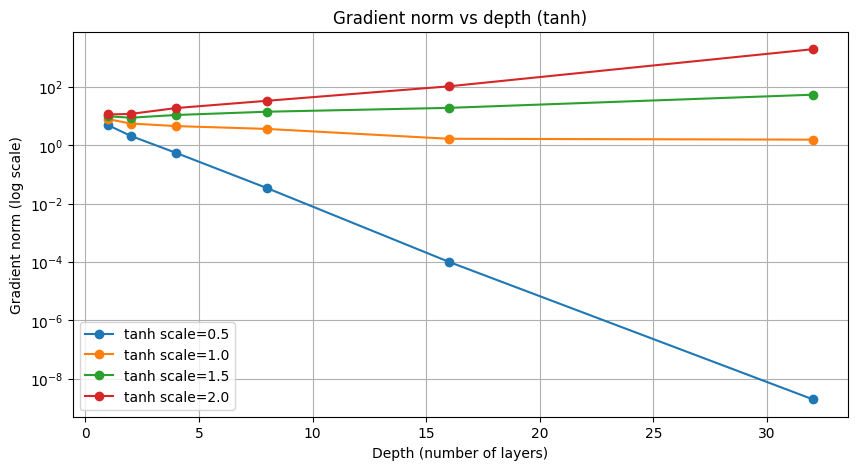

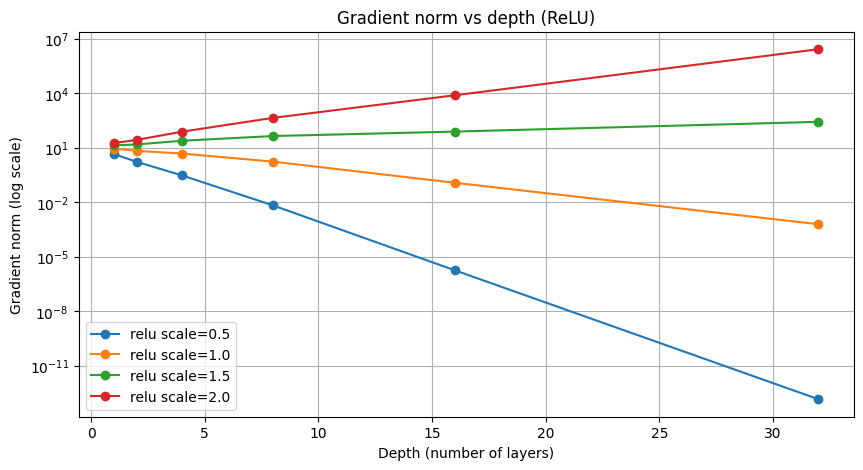

数值观察结论：
- 对于 tanh，链式相乘中激活导数均小于等于1（tanh's derivative <= 1），当权重缩放较小时会看到梯度随深度指数下降（梯度消失）。
- 如果权重缩放大（例如 scale>1），乘积可以导致梯度增大（梯度爆炸）。
- ReLU 导数在激活区间为 0 或 1，平均导数接近某个常数(≤1)，因此 ReLU 相较于 tanh 更不容易发生梯度消失，数值上通常能看到梯度随着深度更稳定。


In [15]:
# 4.1 梯度消失与梯度爆炸：数值实验演示
# 目的：验证在深层网络中，链式相乘会导致梯度随深度呈指数衰减或增长；对比 tanh 与 ReLU 的效果。
import torch
import numpy as np
import matplotlib.pyplot as plt

def gradient_norm_vs_depth(activation='tanh', depth_list=None, scale_list=None, dim=128, trials=5):
    if depth_list is None:
        depth_list = [1,2,4,8,16,32]
    if scale_list is None:
        scale_list = [0.5, 1.0, 1.5, 2.0]
    results = {}
    for scale in scale_list:
        avg_norms = []
        for depth in depth_list:
            norms = []
            for t in range(trials):
                torch.manual_seed(t)
                # random input
                x = torch.randn(1, dim, requires_grad=True)
                h = x
                Ws = []
                for d in range(depth):
                    W = (scale/np.sqrt(dim)) * torch.randn(dim, dim)
                    Ws.append(W)
                    h = h @ W
                    if activation == 'tanh':
                        h = torch.tanh(h)
                    elif activation == 'relu':
                        h = torch.relu(h)
                    else:
                        raise ValueError('Unknown activation')
                # scalar loss
                loss = h.sum()
                # compute gradient wrt input
                grad = torch.autograd.grad(loss, x, retain_graph=False)[0]
                norms.append(grad.norm().item())
            avg_norms.append(np.mean(norms))
        results[scale] = avg_norms
    return depth_list, results

# 运行实验
depths, tanh_res = gradient_norm_vs_depth('tanh', depth_list=[1,2,4,8,16,32], scale_list=[0.5,1.0,1.5,2.0], dim=128, trials=3)
depths, relu_res = gradient_norm_vs_depth('relu', depth_list=[1,2,4,8,16,32], scale_list=[0.5,1.0,1.5,2.0], dim=128, trials=3)

# 绘图：梯度范数随深度变化（对数 y 轴便于观察衰减/增长）
plt.figure(figsize=(10,5))
for scale, norms in tanh_res.items():
    plt.plot(depths, norms, marker='o', label=f'tanh scale={scale}')
plt.yscale('log')
plt.xlabel('Depth (number of layers)')
plt.ylabel('Gradient norm (log scale)')
plt.title('Gradient norm vs depth (tanh)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
for scale, norms in relu_res.items():
    plt.plot(depths, norms, marker='o', label=f'relu scale={scale}')
plt.yscale('log')
plt.xlabel('Depth (number of layers)')
plt.ylabel('Gradient norm (log scale)')
plt.title('Gradient norm vs depth (ReLU)')
plt.legend()
plt.grid(True)
plt.show()

# 简要结论打印
print('数值观察结论：')
print('- 对于 tanh，链式相乘中激活导数均小于等于1（tanh\'s derivative <= 1），当权重缩放较小时会看到梯度随深度指数下降（梯度消失）。')
print('- 如果权重缩放大（例如 scale>1），乘积可以导致梯度增大（梯度爆炸）。')
print('- ReLU 导数在激活区间为 0 或 1，平均导数接近某个常数(≤1)，因此 ReLU 相较于 tanh 更不容易发生梯度消失，数值上通常能看到梯度随着深度更稳定。')

In [16]:
# 模拟数值不稳定现象，并验证不同初始化策略对深层网络的影响
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = torch.device('cpu')

# helper: build MLP with given depth and activation
def build_mlp(depth=20, width=256, activation='sigmoid'):
    layers = []
    input_dim = width
    # first layer input dim keep as width (we'll feed width-dim input)
    for i in range(depth):
        layers.append(nn.Linear(width, width))
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'leakyrelu':
            layers.append(nn.LeakyReLU(negative_slope=0.1))
    return nn.Sequential(*layers)

# utility: initialize model weights with a function
def init_model(model, init_fn):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            init_fn(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)

# utility: forward and compute gradient norms wrt loss (sum of outputs)
def grad_norms_for_model(model, x):
    model.zero_grad()
    out = model(x)
    loss = out.sum()
    loss.backward()
    norms = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            g = param.grad
            norms.append(g.norm().item() if g is not None else 0.0)
    return norms

# prepare input
batch = 16
width = 256
x = torch.randn(batch, width, device=device)

# 1) Sigmoid activation, Gaussian std=1 initialization
model_sig = build_mlp(depth=20, width=width, activation='sigmoid')
init_model(model_sig, lambda w: nn.init.normal_(w, mean=0.0, std=1.0))
model_sig.to(device)
print('Running Sigmoid + N(0,1) init...')
try:
    norms_sig = grad_norms_for_model(model_sig, x)
    print('Gradient norms (first 10 weights):', norms_sig[:10])
    print('Gradient norms (last 10 weights):', norms_sig[-10:])
except Exception as e:
    print('Error during Sigmoid init run:', e)

# 2) ReLU activation, large std=10 initialization (may cause NaN)
model_relu_large = build_mlp(depth=20, width=width, activation='relu')
init_model(model_relu_large, lambda w: nn.init.normal_(w, mean=0.0, std=10.0))
model_relu_large.to(device)
print('\nRunning ReLU + N(0,10) init (expect possible NaNs)...')
try:
    norms_relu_large = grad_norms_for_model(model_relu_large, x)
    any_nan = any(np.isnan(n) for n in norms_relu_large)
    print('Any NaN in gradients?', any_nan)
    print('Gradient norms (first 10 weights):', norms_relu_large[:10])
    print('Gradient norms (last 10 weights):', norms_relu_large[-10:])
except Exception as e:
    print('Error during ReLU large init run:', e)

# 3) Xavier initialization + ReLU (or LeakyReLU)
model_xavier = build_mlp(depth=20, width=width, activation='relu')
init_model(model_xavier, lambda w: nn.init.xavier_uniform_(w))
model_xavier.to(device)
print('\nRunning ReLU + Xavier init...')
try:
    norms_xavier = grad_norms_for_model(model_xavier, x)
    print('Gradient norms (first 10 weights):', norms_xavier[:10])
    print('Gradient norms (last 10 weights):', norms_xavier[-10:])
    # stats
    arr = np.array(norms_xavier)
    print('grad norm stats: min={:.3e}, max={:.3e}, mean={:.3e}'.format(arr.min(), arr.max(), arr.mean()))
except Exception as e:
    print('Error during Xavier init run:', e)

print('\n实验完成：请观察上面的梯度范数输出以判定是否存在梯度消失/爆炸或 NaN。')

Running Sigmoid + N(0,1) init...
Gradient norms (first 10 weights): [3439.625, 2162.369140625, 1627.4461669921875, 1431.818603515625, 1162.327880859375, 839.8568725585938, 691.1771240234375, 764.8273315429688, 479.3949279785156, 395.79925537109375]
Gradient norms (last 10 weights): [408.0342102050781, 302.5595703125, 225.57484436035156, 175.3842315673828, 146.0856475830078, 129.95310974121094, 117.31229400634766, 117.13965606689453, 140.9948272705078, 150.00778198242188]

Running ReLU + N(0,10) init (expect possible NaNs)...
Any NaN in gradients? True
Gradient norms (first 10 weights): [nan, inf, inf, inf, inf, inf, inf, inf, inf, inf]
Gradient norms (last 10 weights): [inf, inf, inf, inf, inf, inf, inf, inf, inf, inf]

Running ReLU + Xavier init...
Gradient norms (first 10 weights): [3.397662401199341, 3.8801167011260986, 4.7172017097473145, 4.779274940490723, 5.367990493774414, 5.6186652183532715, 6.352112293243408, 5.874261856079102, 5.7970733642578125, 5.457614421844482]
Gradient n

Running Sigmoid_N1 (activation=sigmoid) ...
  any_nonfinite: False
  sample norms (first 8): [0.43743527 0.31648311 0.28412819 0.21446221 0.17969236 0.14024489
 0.12863041 0.09657773]
Running ReLU_N10 (activation=relu) ...
  any_nonfinite: True
  non-finite grad at weight-layer indices: [19]
  sample norms (first 8): [inf inf inf inf inf inf inf inf]
Running ReLU_Xavier (activation=relu) ...
  any_nonfinite: False
  sample norms (first 8): [0.00038267 0.00064428 0.0007602  0.00088764 0.00102243 0.00111217
 0.00118425 0.0011887 ]


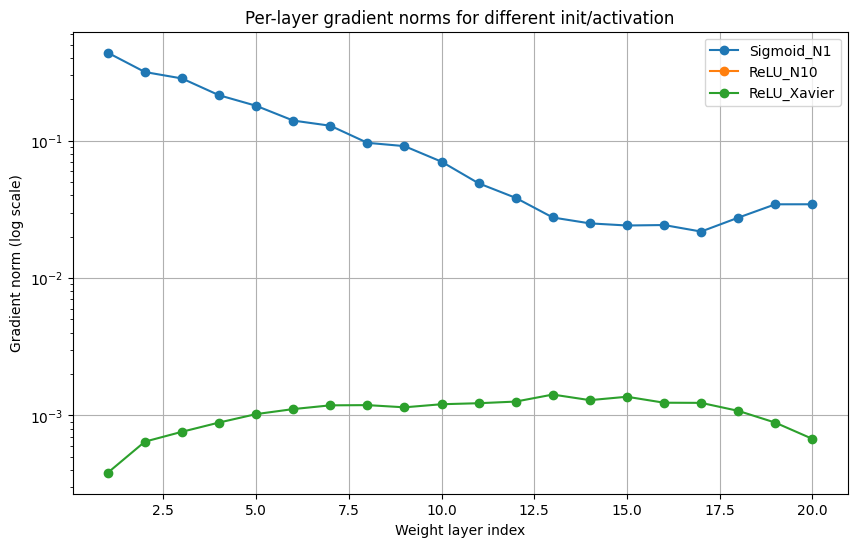

已保存每组实验摘要到 grad20_*.npz


In [17]:
# 改进版：20 层数值稳定性实验（使用 mean loss、逐层 NaN/inf 检测并绘图）
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cpu')

# 重用或复刻一个简单的 build/init 函数
def build_mlp(depth=20, width=256, activation='sigmoid'):
    layers = []
    for i in range(depth):
        layers.append(nn.Linear(width, width))
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'leakyrelu':
            layers.append(nn.LeakyReLU(negative_slope=0.1))
    return nn.Sequential(*layers)

def init_model(model, init_fn):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            init_fn(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)

# 使用 mean loss，收集每个 weight 参数的梯度范数并检测是否为有限值
def grad_norms_and_finites(model, x):
    model.zero_grad()
    out = model(x)
    loss = out.mean()
    loss.backward()
    norms = []
    finites = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            g = param.grad
            if g is None:
                norms.append(0.0)
                finites.append(True)
            else:
                norms.append(float(g.norm().item()))
                finites.append(bool(torch.isfinite(g).all().item()))
    return norms, finites

# 运行三组实验并绘图
batch = 64
width = 256
x = torch.randn(batch, width, device=device)

cases = [
    ('Sigmoid_N1', 'sigmoid', lambda w: nn.init.normal_(w, mean=0.0, std=1.0)),
    ('ReLU_N10', 'relu', lambda w: nn.init.normal_(w, mean=0.0, std=10.0)),
    ('ReLU_Xavier', 'relu', lambda w: nn.init.xavier_uniform_(w)),
]

results = {}
for name, act, init_fn in cases:
    model = build_mlp(depth=20, width=width, activation=act).to(device)
    init_model(model, init_fn)
    print(f'Running {name} (activation={act}) ...')
    try:
        norms, finites = grad_norms_and_finites(model, x)
        results[name] = {'norms': norms, 'finites': finites}
        any_nonfinite = not all(finites)
        print(f'  any_nonfinite: {any_nonfinite}')
        if any_nonfinite:
            bad_idx = [i for i, f in enumerate(finites) if not f]
            print('  non-finite grad at weight-layer indices:', bad_idx)
        print('  sample norms (first 8):', np.array(norms)[:8])
    except Exception as e:
        print(f'  Error during {name}:', e)

# 绘图：每层梯度范数（对数刻度）
plt.figure(figsize=(10,6))
for name, res in results.items():
    norms = np.array(res['norms'])
    plt.plot(np.arange(1, len(norms)+1), norms, marker='o', label=name)
plt.yscale('log')
plt.xlabel('Weight layer index')
plt.ylabel('Gradient norm (log scale)')
plt.title('Per-layer gradient norms for different init/activation')
plt.legend()
plt.grid(True)
plt.show()

# 保存摘要
for name, res in results.items():
    np.savez(f'grad20_{name}.npz', norms=np.array(res['norms']), finites=np.array(res['finites'], dtype=np.bool_))
print('已保存每组实验摘要到 grad20_*.npz')

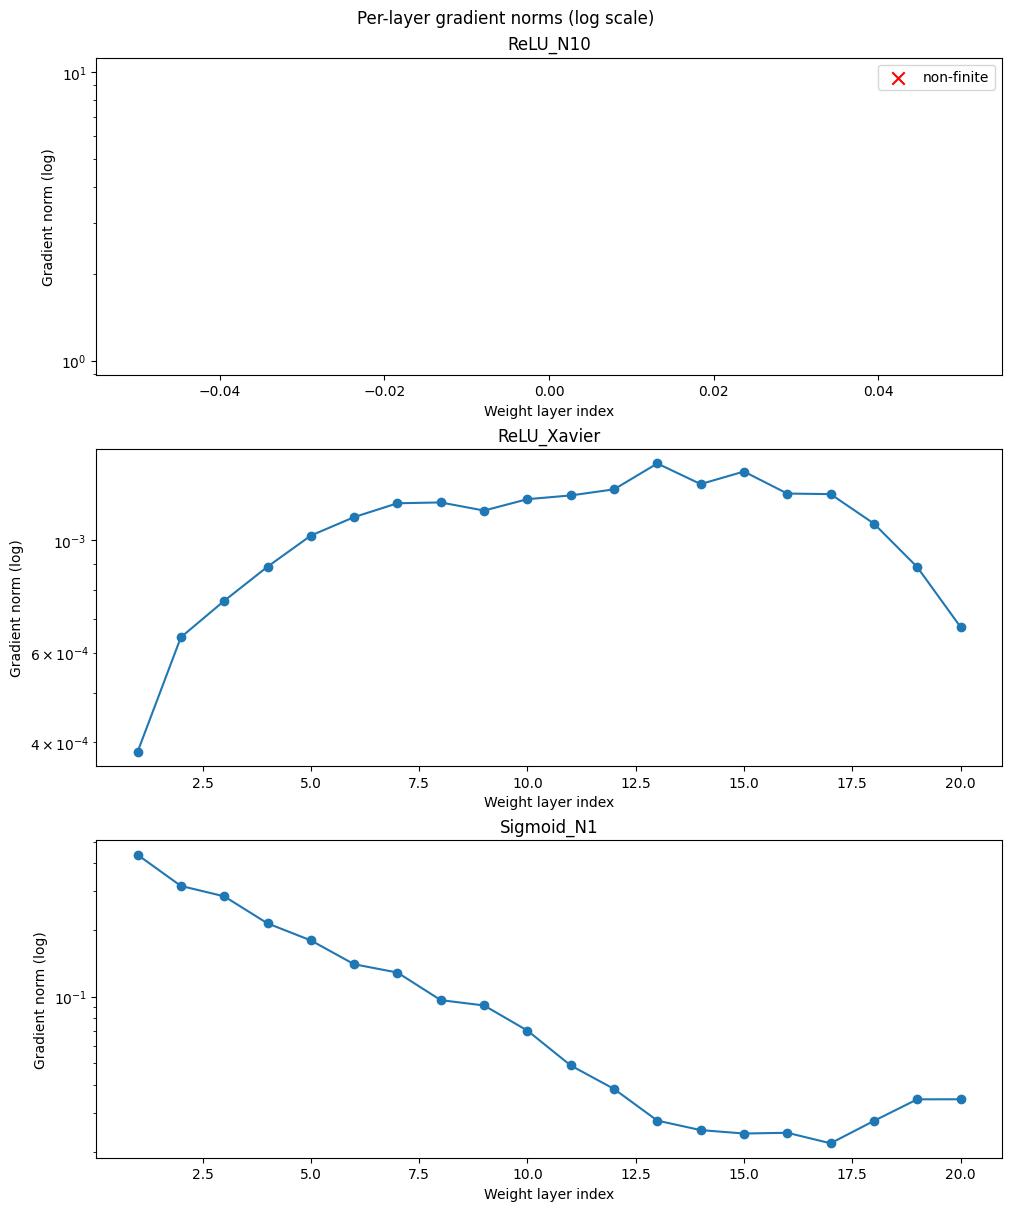


Summary:
- ReLU_N10: layers=20, non-finite=1, min=inf, max=inf, mean=inf
- ReLU_Xavier: layers=20, non-finite=0, min=3.827e-04, max=1.419e-03, mean=1.061e-03
- Sigmoid_N1: layers=20, non-finite=0, min=2.182e-02, max=4.374e-01, mean=1.133e-01

图片已保存为 grad20_summary.png


In [18]:
# 可视化每组实验并标注非有限梯度层，保存图片和统计摘要
import glob
import numpy as np
import matplotlib.pyplot as plt

files = sorted(glob.glob('grad20_*.npz'))
if len(files) == 0:
    print('未找到任何 grad20_*.npz 文件，请先运行对应实验单元。')
else:
    # 每个文件绘成子图
    n = len(files)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 4*n), constrained_layout=True)
    if n == 1:
        axes = [axes]
    summary = []
    for ax, f in zip(axes, files):
        data = np.load(f)
        norms = data['norms']
        finites = data['finites']
        x = np.arange(1, len(norms)+1)
        ax.plot(x, norms, marker='o')
        ax.set_yscale('log')
        ax.set_xlabel('Weight layer index')
        ax.set_ylabel('Gradient norm (log)')
        title = f.split('grad20_')[-1].replace('.npz','')
        ax.set_title(title)
        # 标注非有限值层
        bad_idx = np.where(~finites)[0]
        if bad_idx.size > 0:
            ax.scatter(bad_idx+1, np.maximum(1e-300, np.abs(norms[bad_idx])), color='red', marker='x', s=80, label='non-finite')
            ax.legend()
        # 统计信息
        finite_norms = norms[np.array(finites, dtype=bool)]
        stats = {
            'file': f,
            'name': title,
            'n_layers': len(norms),
            'n_nonfinite': int((~np.array(finites)).sum()),
            'min': float(np.min(finite_norms)) if finite_norms.size>0 else float('nan'),
            'max': float(np.max(finite_norms)) if finite_norms.size>0 else float('nan'),
            'mean': float(np.mean(finite_norms)) if finite_norms.size>0 else float('nan')
        }
        summary.append(stats)
    out_png = 'grad20_summary.png'
    fig.suptitle('Per-layer gradient norms (log scale)')
    fig.savefig(out_png, dpi=200)
    plt.show()

    # 打印汇总统计
    print('\nSummary:')
    for s in summary:
        print(f"- {s['name']}: layers={s['n_layers']}, non-finite={s['n_nonfinite']}, min={s['min']:.3e}, max={s['max']:.3e}, mean={s['mean']:.3e}")
    print(f"\n图片已保存为 {out_png}")